# EDA: Análise Exploratória de Vendas Mensais (2009–2023)

**Objetivo:** Atender ao caso de uso da disciplina:  
Uma empresa de varejo está enfrentando dificuldades para prever a demanda de seus produtos em períodos específicos do ano, como Natal, Black Friday e Páscoa. Historicamente, a demanda nesses períodos tende a crescer em comparação aos meses regulares, porém, sem uma previsão precisa, a empresa sofre tanto com a falta de estoque em alguns períodos quanto com excesso em outros. Com isso, o desafio é identificar um padrão sazonal na série temporal de vendas para melhorar a precisão das previsões e ajustar o estoque de acordo com a demanda esperada.

Os dados de vendas mensais dos últimos cinco anos foram disponibilizados. A tarefa do estudante será avaliar a presença de sazonalidade na série temporal, compreender sua natureza e propor um modelo adequado para capturar esse padrão. Para isso, a análise deverá considerar técnicas de decomposição para dividir a série em componentes de tendência, sazonalidade e ruído, bem como explorar o uso de modelos SARIMA (Seasonal ARIMA) para uma modelagem mais precisa da sazonalidade.

Com base nos dados fornecidos: 
1- A série apresenta sazonalidade? Justifique sua resposta com base nas análises exploratórias.

2- Qual modelo de série temporal você recomendaria para capturar a sazonalidade identificada? Explique por que escolheu esse modelo e descreva os passos para configurá-lo.

3- Que estratégias a empresa poderia implementar para ajustar seu estoque de acordo com as previsões sazonais obtidas a partir da sua análise?

**Dataset:** `vendas_varejo_15_anos.xlsx` — 15 anos de vendas mensais de varejo 
(180 observações), com sazonalidade de Black Friday, Natal e Páscoa. Como não foi 
diponibilizado os dados no caso de uso e não consegui resposta a mensagem enviada 
solicitei a uma LLM a criação de dados fictícios para aplicar a análise

Este material foi adaptado do material da disciplina Ciência de Dados do curso Cientista de Dados com
Python e Inteligência Artificial que ministro na Treina Recife

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Configurações de visualização
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# Mostrar todas as colunas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [2]:
# Funções Auxiliares
def formatar_periodo(df, freq=None):
    """
    Retorna o primeiro e último dia do índice formatados conforme a frequência da série.
    
    - Anual → apenas o ano (2009)
    - Mensal → mes/ano (01/2009)
    - Diária → dd/mm/aaaa (01/01/2009)
    - Sub-diária → timestamp completo (01/01/2009 14:30:00)
    """
    if freq is None:
        freq = pd.infer_freq(df.index)
    data_min = df.index.min()
    data_max = df.index.max()
    
    if freq is None:
        # Tenta inferir pela diferença entre observações
        diff = df.index.to_series().diff().median()
        if diff >= pd.Timedelta(days=365):
            freq = 'A'
        elif diff >= pd.Timedelta(days=28):
            freq = 'M'
        elif diff >= pd.Timedelta(days=1):
            freq = 'D'
        else:
            freq = 'H'
    
    # Mapear frequência para formato
    if freq.startswith(('A', 'Y', 'AS', 'YS', 'YE', 'AE')):  # Anual
        fmt = '%Y'
        rotulo = 'anual'
    elif freq.startswith(('M', 'MS', 'ME')):  # Mensal
        fmt = '%m/%Y'
        rotulo = 'mensal'
    elif freq.startswith(('D',)):  # Diária
        fmt = '%d/%m/%Y'
        rotulo = 'diária'
    elif freq.startswith(('Q', 'QS')):  # Trimestral
        fmt = '%m/%Y'
        rotulo = 'trimestral'
    elif freq.startswith(('W',)):  # Semanal
        fmt = '%d/%m/%Y'
        rotulo = 'semanal'
    else:  # Sub-diária (horária, minutal, etc.)
        fmt = '%d/%m/%Y %H:%M:%S'
        rotulo = 'sub-diária'
    
    inicio = data_min.strftime(fmt)
    fim = data_max.strftime(fmt)
    
    return {
        'frequencia': freq,
        'rotulo': rotulo,
        'inicio': inicio,
        'fim': fim,
        'formato': fmt
    }

In [3]:
def verificar_serie(df, freq=None):
    """
    Verifica a série temporal: tipo do índice, frequência, lacunas,
    duplicatas, múltiplas por período, nulos, negativos e zeros.
    Retorna quantidades E detalhes de cada problema.
    """
    # 1. Verifica se é uma Série Temporal
    tipo = type(df.index).__name__
    if tipo != 'DatetimeIndex':
        return {
            'mensagem':  '❌ Não foi identificado como uma série temporal',
            'tipo': tipo,
            'frequencia': None,
            'esperado': None,
            'observado': None,
            'lacunas': None,
            'lacunas_datas': None,
            'duplicatas': None,
            'duplicatas_datas': None,
            'multiplas': None,
            'multiplas_detalhe': None,
            'nulos': None,
            'negativos': None,
            'zeros': None
        } 
    
    # 2. Determina a Frequência 
    if freq is None:
        freq = pd.infer_freq(df.index)
        if freq is None:
            freq = 'D'

    # 3. Total esperado vs observado
    indice_esperado = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq=freq
    )

    # 4. Lacunas — quais datas estão faltando
    lacunas_datas = indice_esperado.difference(df.index)

    # 5. Duplicatas — quais datas estão repetidas
    mascara_duplicatas = df.index.duplicated(keep=False)  
    df_duplicatas = df[mascara_duplicatas]
    duplicatas_datas = df_duplicatas.index.unique().sort_values()

    # 6. Múltiplas por período — quais períodos têm mais de 1 observação
    mapa_periodo = {
        'A': 'A', 'AS': 'A', 'Y': 'A', 'YS': 'A', 'AE': 'A', 'YE': 'A',
        'Q': 'Q', 'QS': 'Q', 'QE': 'Q',
        'M': 'M', 'MS': 'M', 'ME': 'M',
        'W': 'W',
        'D': 'D',
        'H': 'H', 'h': 'H',
        'T': 'T', 'min': 'T',
        'S': 'S',
    }
    codigo_periodo = mapa_periodo.get(freq, freq[0] if freq else 'D')
    contagem = df.index.to_period(codigo_periodo).value_counts().sort_index()
    periodos_multiplos = contagem[contagem > 1]

    multiplas_detalhe = []
    for periodo, qtd in periodos_multiplos.items():
        obs = df.loc[periodo.start_time:periodo.end_time]
        for idx, row in obs.iterrows():
            multiplas_detalhe.append({
                'periodo': str(periodo),
                'data': idx,
                'observacoes_no_periodo': qtd,
                'valores': row.to_dict()
            })

    # 7. Nulos
    nulos = df.isnull().sum().sum()

    # 8. Negativos
    negativos = int((df.select_dtypes(include='number') < 0).sum().sum())

    # 9. Zeros
    zeros = int((df.select_dtypes(include='number') == 0).sum().sum())

    # 10 Gerando a mensagem final
    formata = formatar_periodo(df, freq)
    mensagem = f"""
## Resumo da EDA

### Qualidade dos Dados
- ✅ É uma Série Temporal
- ✅ Frequência: `{formata['frequencia']} ({formata['rotulo']})`
- ✅ {len(df)} observações mensais ({formata['inicio']} a {formata['fim']}) 
"""

    if  len(lacunas_datas) == 0:
        mensagem += f"""
- ✅ {len(lacunas_datas)} lacunas de datas
"""
    else:
        mensagem += f"""
- ❌ Esta série tem as seguintes lacunas no período {lacunas_datas}
"""
    if  nulos == 0:
        mensagem += f"""
- ✅ {nulos} valores nulos
"""
    else:
        mensagem += f"""
- ❌ Esta série tem valores nulos
"""
    if int(df.index.duplicated().sum()) == 0:    
        mensagem += f"""
- ✅ {int(df.index.duplicated().sum())} períodos duplicados
"""
    else:
        memsagem += f"""
- ⚠️ Esta série tem os seguintes péríodos repetidos {duplicatas_datas}
"""
    if len(periodos_multiplos) == 0:    
        mensagem += f"""
- ✅ {len(periodos_multiplos)} períodos com marcações múltiplas
"""
    else:
        memsagem += f"""
- ⚠️ Esta série tem os seguintes péríodos com marcações múltiplas {multiplas_detalhe}
"""

    if negativos == 0:    
        mensagem += f"""
- ✅ {negativos} valores negativos
"""
    else:
        memsagem += f"""
- ⚠️ Esta série tem valores negativos
"""
    if zeros == 0:    
        mensagem += f"""
- ✅ {zeros} valores zerados
"""
    else:
        memsagem += f"""
- ⚠️ Esta série tem valores zerados
"""

    return {
        'mensagem': mensagem,
        'tipo': tipo,
        'frequencia': freq,
        'esperado': len(indice_esperado),
        'observado': len(df),
        'lacunas': len(lacunas_datas),
        'lacunas_datas': list(lacunas_datas.strftime('%d/%m/%Y')),
        'duplicatas': int(df.index.duplicated().sum()),
        'duplicatas_datas': list(duplicatas_datas.strftime('%d/%m/%Y')),
        'multiplas': len(periodos_multiplos),
        'multiplas_detalhe': multiplas_detalhe,
        'nulos': int(nulos),
        'negativos': negativos,
        'zeros': zeros
    }

In [4]:
def calcular_metricas(real, previsto):
    mae = np.mean(np.abs(real - previsto))
    rmse = np.sqrt(np.mean((real - previsto) ** 2))
    mape = np.mean(np.abs((real - previsto) / real)) * 100
    smape = np.mean(2 * np.abs(real - previsto) / (np.abs(real) + np.abs(previsto))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sMAPE': smape}

In [5]:
# Funções para este problema
def interpretar_acf_pacf(serie_acf, serie_pacf, conf_int, nome):
    """
    Interpreta ACF e PACF para sugerir ordens p, q.
    """
    # Contar lags significativos (acima do intervalo de confiança)
    lags_acf_sig = [i for i in range(1, len(serie_acf)) if abs(serie_acf[i]) > conf_int]
    lags_pacf_sig = [i for i in range(1, len(serie_pacf)) if abs(serie_pacf[i]) > conf_int]

    # Verificar corte abrupto (primeiros k lags significativos, depois cai para zero)
    def detectar_corte(lags_sig, max_lag=10):
        for k in range(1, min(max_lag + 1, len(lags_sig) + 1)):
            if k not in lags_sig:
                return k - 1
        return min(len(lags_sig), max_lag)

    corte_acf = detectar_corte(lags_acf_sig)
    corte_pacf = detectar_corte(lags_pacf_sig)

    # Verificar decaimento exponencial (tail-off)
    def decai(lags_sig, max_lag=10):
        return len(lags_sig) > max_lag

    acf_tail = decai(lags_acf_sig)
    pacf_tail = decai(lags_pacf_sig)

    # Lags sazonais significativos (12, 24, 36)
    lags_sazonais_acf = [l for l in [12, 24, 36] if l < len(serie_acf) and abs(serie_acf[l]) > conf_int]
    lags_sazonais_pacf = [l for l in [12, 24, 36] if l < len(serie_pacf) and abs(serie_pacf[l]) > conf_int]

    return {
        'nome': nome,
        'lags_acf_sig': lags_acf_sig[:10],
        'lags_pacf_sig': lags_pacf_sig[:10],
        'corte_acf': corte_acf,
        'corte_pacf': corte_pacf,
        'acf_tail_off': acf_tail,
        'pacf_tail_off': pacf_tail,
        'lags_sazonais_acf': lags_sazonais_acf,
        'lags_sazonais_pacf': lags_sazonais_pacf,
        'qtd_acf_sig': len(lags_acf_sig),
        'qtd_pacf_sig': len(lags_pacf_sig),
    }

In [6]:
def tabela_lags_significativos(interp, conf_int_val):
    """Gera tabela de lags significativos para ACF e PACF."""
    linhas = []
    for lag in range(1, 11):  # lags 1 a 10
        acf_val = acf_diff_s[lag] if lag < len(acf_diff_s) else 0
        pacf_val = pacf_diff_s[lag] if lag < len(pacf_diff_s) else 0
        acf_sig = "✅" if abs(acf_val) > conf_int_val else "—"
        pacf_sig = "✅" if abs(pacf_val) > conf_int_val else "—"
        linhas.append(f"| {lag} | {acf_val:+.3f} {acf_sig} | {pacf_val:+.3f} {pacf_sig} |")
    # Lags sazonais
    for lag in [12, 24, 36]:
        if lag < len(acf_diff_s):
            acf_val = acf_diff_s[lag]
            pacf_val = pacf_diff_s[lag]
            acf_sig = "✅" if abs(acf_val) > conf_int_val else "—"
            pacf_sig = "✅" if abs(pacf_val) > conf_int_val else "—"
            linhas.append(f"| **{lag}** (sazonal) | {acf_val:+.3f} {acf_sig} | {pacf_val:+.3f} {pacf_sig} |")
    return "\n".join(linhas)


## 1. Carregamento dos Dados

Tudo começa com a obtenção dos dados e no caso específico de uma série temporal ter o dataframe com um índice temporal

In [7]:
# Ler arquivo TSV com encoding UTF-16
# df = pd.read_csv('vendas_varejo_15_anos.csv', 
#                  sep='\t', 
#                  parse_dates=['data'], 
#                  encoding='utf-16')
df = pd.read_csv(r"D:\TreinaRecife\Python do Zero até a Análise de Dados\aprendizado\datasets\vendas_mes.csv",
                 parse_dates=['data'], )
# Definir 'data' como índice
df = df.set_index('data')
df = df.sort_index()
if type(df.index).__name__ != 'DatetimeIndex':
    print('Esta não é uma Série Temporal')
    raise TypeError(f"Esperado DatetimeIndex, mas recebeu {type(df.index).__name__}")
print(f"Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"Período: {df.index.min().date()} a {df.index.max().date()}")
print(f"\nColunas: {list(df.columns)}")
print(f"Tipos:\n{df.dtypes}")
# Criar cópia para preservar o original
df_eda = df.copy()

Dimensões: 64 linhas × 4 colunas
Período: 2011-01-01 a 2016-04-01

Colunas: ['ano', 'mes', 'mes_nome', 'vendas']
Tipos:
ano         int64
mes         int64
mes_nome      str
vendas      int64
dtype: object


## 2. Análise Exploratória dos Dados (EDA)

Antes de qualquer análise, precisamos entender:
- Se temos uma série temporal de fato
- Quais colunas existem e seus tipos
- Se há valores nulos
- As primeiras e últimas observações
- Quantidade de linhas

In [8]:
# Informações sobre tipos e nulidade
print("=" * 60)
print("INFORMAÇÕES DO DATAFRAME")
print("=" * 60)
df_eda.info()
print("\n" + "=" * 60)
print("VALORES NULOS POR COLUNA")
print("=" * 60)
print(df_eda.isnull().sum())
print("\n" + "=" * 60)
print("TIPOS DE DADOS")
print("=" * 60)
print(df_eda.dtypes)
print("\n" + "=" * 60)
print("PRIMEIRAS 5 LINHAS:")
print("=" * 60)
display(df_eda.head())
print("\n" + "=" * 60)
print("ÚLTIMAS 5 LINHAS:")
print("=" * 60)
display(df_eda.tail())
verifica = verificar_serie(df_eda)
display(Markdown(verifica['mensagem']) )

INFORMAÇÕES DO DATAFRAME
<class 'pandas.DataFrame'>
DatetimeIndex: 64 entries, 2011-01-01 to 2016-04-01
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ano       64 non-null     int64
 1   mes       64 non-null     int64
 2   mes_nome  64 non-null     str  
 3   vendas    64 non-null     int64
dtypes: int64(3), str(1)
memory usage: 2.5 KB

VALORES NULOS POR COLUNA
ano         0
mes         0
mes_nome    0
vendas      0
dtype: int64

TIPOS DE DADOS
ano         int64
mes         int64
mes_nome      str
vendas      int64
dtype: object

PRIMEIRAS 5 LINHAS:


,ano,mes,mes_nome,vendas
data,,,,
2011-01-01,2011,1,Janeiro,88163
2011-02-01,2011,2,Fevereiro,726375
2011-03-01,2011,3,Março,763567
2011-04-01,2011,4,Abril,737713
2011-05-01,2011,5,Maio,719562



ÚLTIMAS 5 LINHAS:


,ano,mes,mes_nome,vendas
data,,,,
2015-12-01,2015,12,Dezembro,1126236
2016-01-01,2016,1,Janeiro,1215286
2016-02-01,2016,2,Fevereiro,1212927
2016-03-01,2016,3,Março,1275746
2016-04-01,2016,4,Abril,1046688



## Resumo da EDA

### Qualidade dos Dados
- ✅ É uma Série Temporal
- ✅ Frequência: `MS (mensal)`
- ✅ 64 observações mensais (01/2011 a 04/2016) 

- ✅ 0 lacunas de datas

- ✅ 0 valores nulos

- ✅ 0 períodos duplicados

- ✅ 0 períodos com marcações múltiplas

- ✅ 0 valores negativos

- ✅ 0 valores zerados


## 3.Análisa da Necessidade das Variáveis

Com os dados já estudados é necessário analisar a importância das variáveis exógenas existentes. Se de fato estas variáveis nos ajudarão na nossa análise.

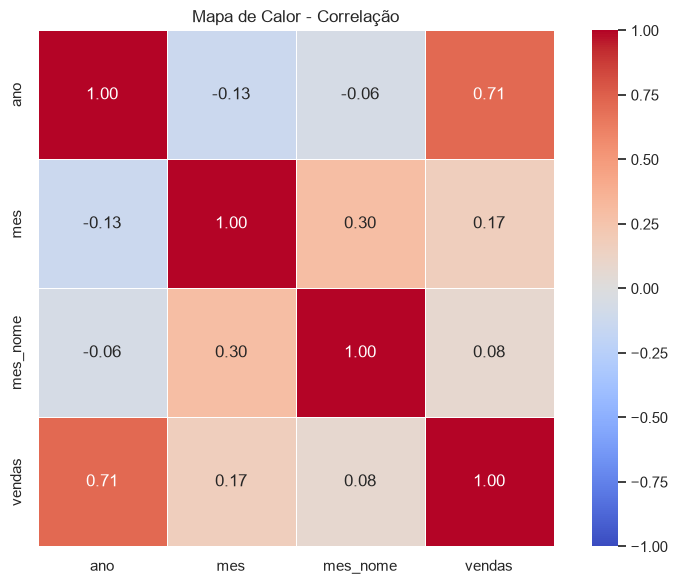

In [9]:
# Transforma a variável string em categórica
df_eda['mes_nome'] = df_eda['mes_nome'].astype('category').cat.codes

# Calcula a matriz de correlação
corr = df_eda.corr(numeric_only=True)

# Cria o mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,           # mostra os valores nas células
    cmap='coolwarm',      # paleta de cores (azul=negativo, vermelho=positivo)
    center=0,             # centraliza o 0 (cores neutras no meio)
    fmt='.2f',            # 2 casas decimais
    square=True,          # células quadradas
    linewidths=0.5,       # linha entre células
    vmin=-1, vmax=1       # escala fixa de -1 a 1
)
plt.title('Mapa de Calor - Correlação')
plt.tight_layout()
plt.show()

### Verificação das necessidade das colunas

**Decisão:**
- `ano` → **remover** (pode ser derivada do índice com `df.index.year`)
- `mes` → **manter temporariamente** (mantido para destacar Natal e Black Friday)
- `mes_nome` → **remover** (pode ser derivada de `mes`)
- `vendas` → **manter** (variável alvo)

In [10]:
# Remover colunas redundantes
colunas_remover = ['ano',  'mes_nome']
df_eda = df_eda.drop(columns=colunas_remover)

print(f"Colunas removidas: {colunas_remover}")
print(f"Colunas restantes: {list(df_eda.columns)}")
print(f"Shape: {df_eda.shape}")
print("\nDataFrame após limpeza:")
print("=" * 60)
print("10 primeiros meses após limpeza")
print("=" * 60)
display(df_eda.head(10))

Colunas removidas: ['ano', 'mes_nome']
Colunas restantes: ['mes', 'vendas']
Shape: (64, 2)

DataFrame após limpeza:
10 primeiros meses após limpeza


,mes,vendas
data,,
2011-01-01,1,88163
2011-02-01,2,726375
2011-03-01,3,763567
2011-04-01,4,737713
2011-05-01,5,719562
2011-06-01,6,753380
2011-07-01,7,819820
2011-08-01,8,825694
2011-09-01,9,813683


## 4. Análise Temporal

Com os dados já estudados é necessário analisar a importância das variáveis exógenas existentes. Se de fato estas variáveis nos ajudarão na nossa análise.

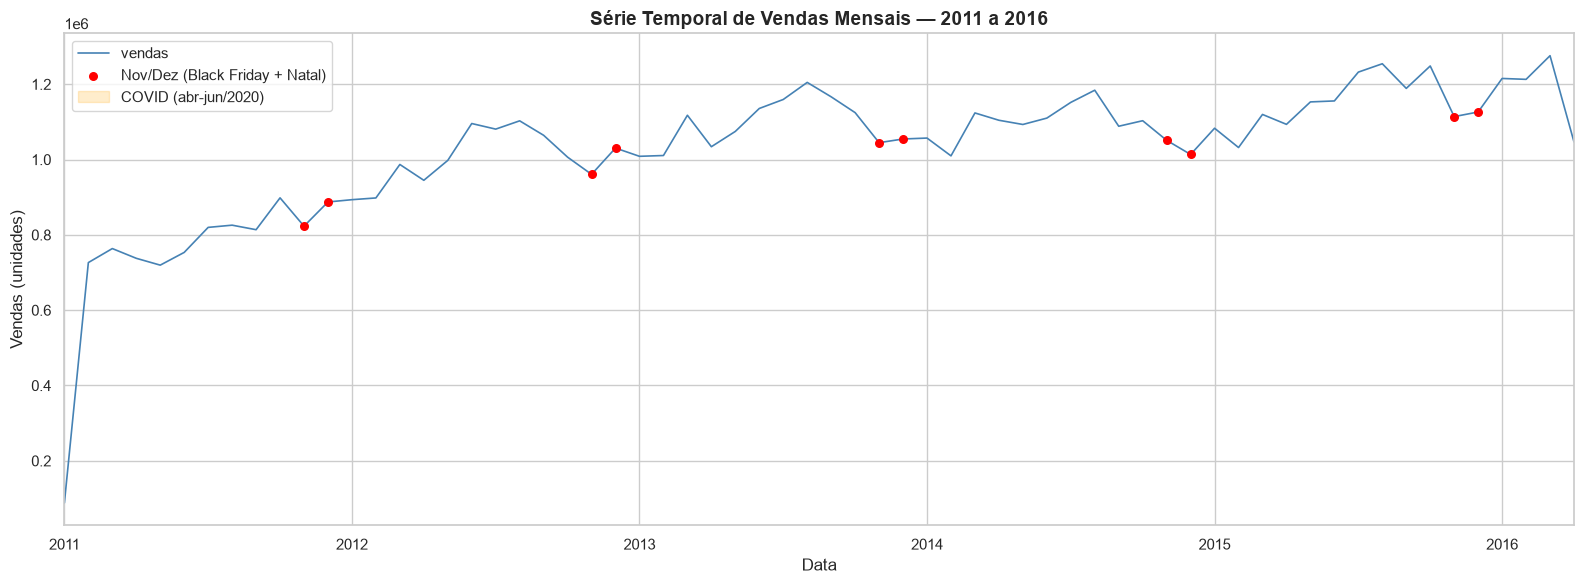

In [17]:
# Gráfico com a série completa

# Destacados os meses de novembro e dezembro 
# Destacao o período da Covid-19

fig, ax = plt.subplots(figsize=(16, 6))

df_eda['vendas'].plot(ax=ax, color='steelblue', linewidth=1.2)

# Destacar novembro e dezembro
nov_dez = df_eda[df_eda['mes'].isin([11, 12])]
ax.scatter(nov_dez.index, nov_dez['vendas'], color='red', s=30, 
           label='Nov/Dez (Black Friday + Natal)', zorder=5)

# Destacar período COVID
covid = df_eda.loc['2020-04':'2020-06']
ax.axvspan('2020-04', '2020-06', alpha=0.2, color='orange', label='COVID (abr-jun/2020)')

ax.set_title(f'Série Temporal de Vendas Mensais — {df.index.min().year} a {df.index.max().year}', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Vendas (unidades)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

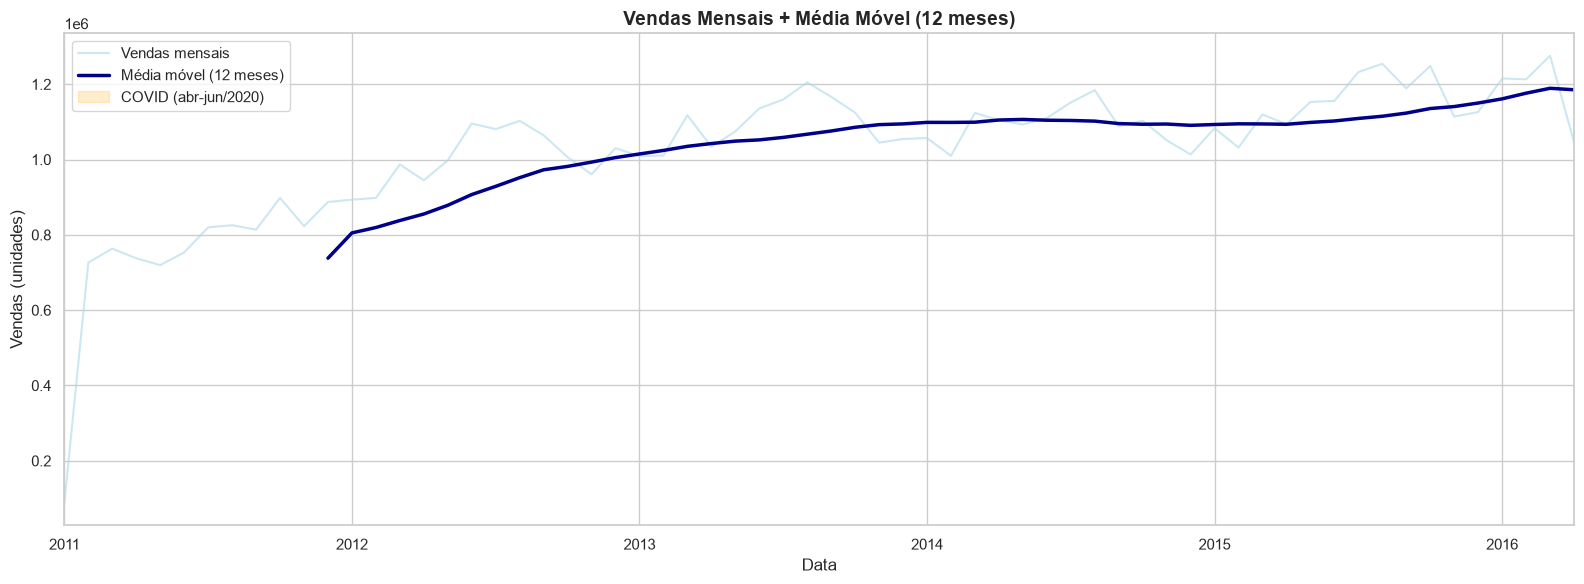

In [12]:
# Visualização da Tendência (Média móve).
fig, ax = plt.subplots(figsize=(16, 6))

df_eda['vendas'].plot(ax=ax, color='lightblue', alpha=0.6, label='Vendas mensais')
df_eda['vendas'].rolling(window=12).mean().plot(ax=ax, color='darkblue', 
                                                   linewidth=2.5, label='Média móvel (12 meses)')
ax.axvspan('2020-04', '2020-06', alpha=0.2, color='orange', label='COVID (abr-jun/2020)')
ax.set_title('Vendas Mensais + Média Móvel (12 meses)', fontsize=14, fontweight='bold')
ax.set_xlabel('Data')
ax.set_ylabel('Vendas (unidades)')
ax.legend()
plt.tight_layout()
plt.show()

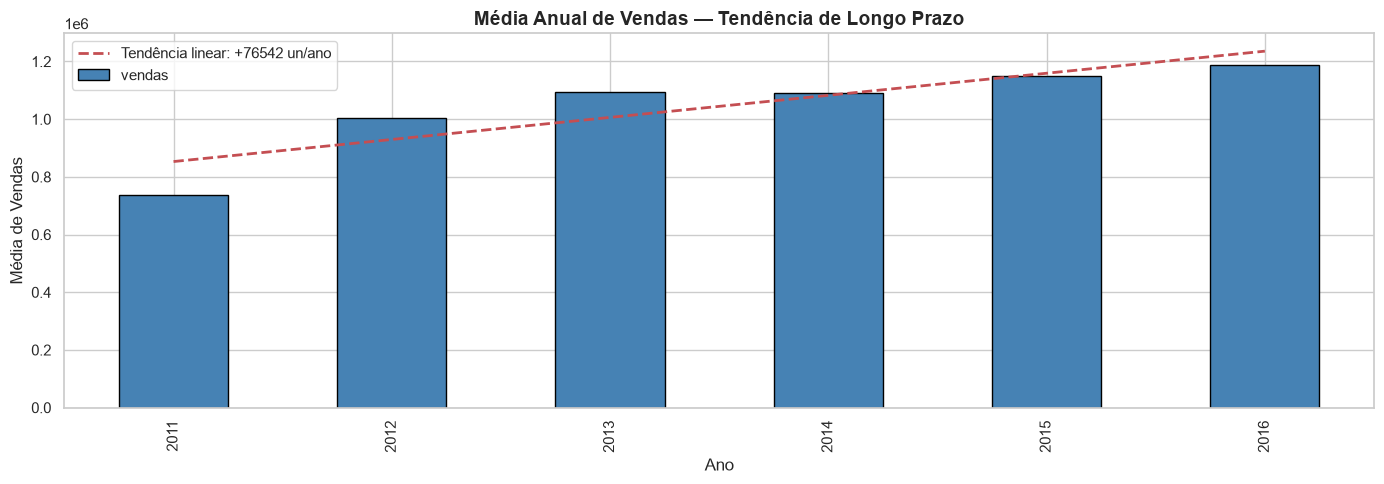

Crescimento linear aproximado: 76542 unidades/ano
2009: 738049 → 2023: 1187662
Crescimento total: 60.9%


In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

vendas_anuais = df_eda.groupby(df_eda.index.year)['vendas'].mean()
vendas_anuais.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

# Linha de tendência
x = np.arange(len(vendas_anuais))
z = np.polyfit(x, vendas_anuais.values, 1)
p = np.poly1d(z)
ax.plot(x, p(x), 'r--', linewidth=2, label=f'Tendência linear: +{z[0]:.0f} un/ano')

ax.set_title('Média Anual de Vendas — Tendência de Longo Prazo', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Média de Vendas')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Crescimento linear aproximado: {z[0]:.0f} unidades/ano")
print(f"2009: {vendas_anuais.iloc[0]:.0f} → 2023: {vendas_anuais.iloc[-1]:.0f}")
print(f"Crescimento total: {((vendas_anuais.iloc[-1] / vendas_anuais.iloc[0]) - 1) * 100:.1f}%")

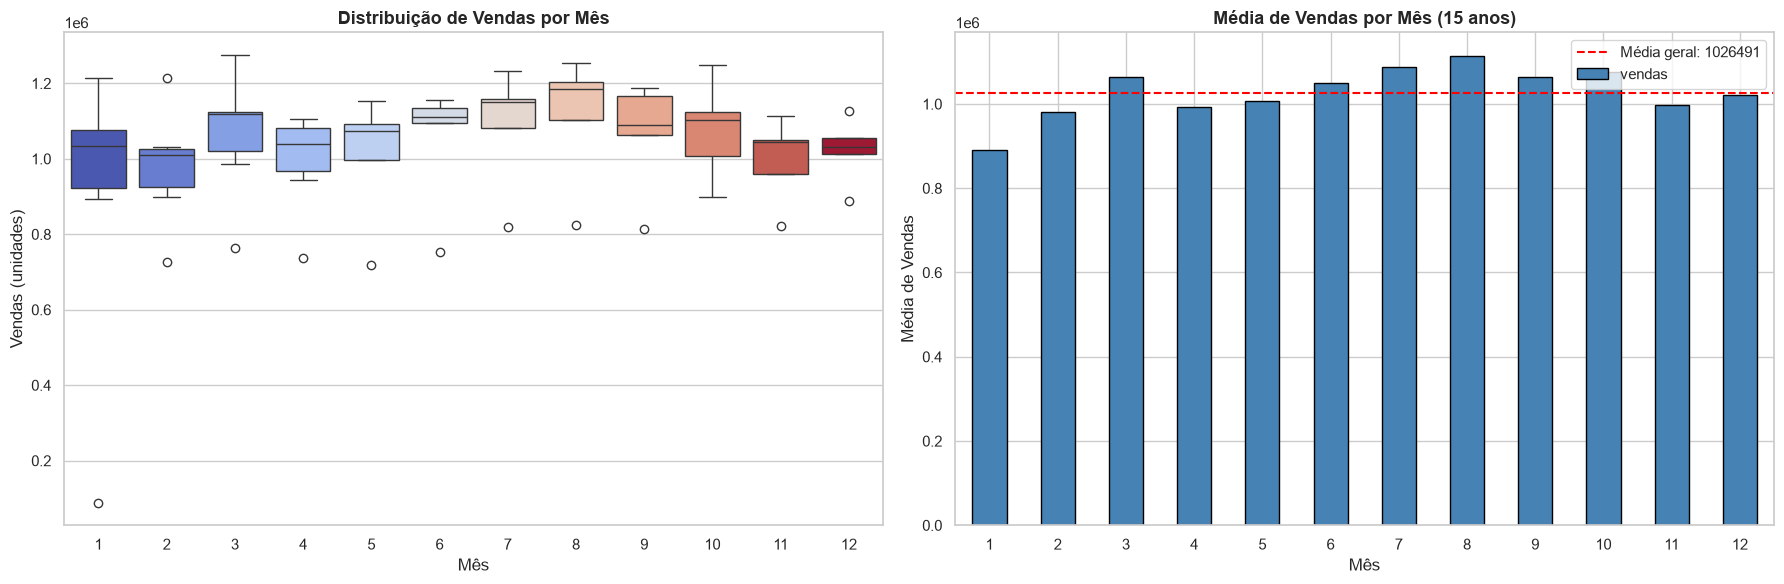


Média de vendas por mês:
mes
1      890918.50
2      981598.17
3     1064535.00
4      993501.83
5     1007619.40
6     1050042.40
7     1088795.00
8     1114346.00
9     1064377.80
10    1076117.80
11     998724.80
12    1022394.40
Name: vendas, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot por mês
sns.boxplot(data=df_eda, x='mes', y='vendas', ax=axes[0], hue='mes', palette='coolwarm', legend=False)
axes[0].set_title('Distribuição de Vendas por Mês', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Vendas (unidades)')

# Média por mês (barplot)
medias_mensais = df_eda.groupby('mes')['vendas'].mean()
medias_mensais.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Média de Vendas por Mês (15 anos)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Média de Vendas')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# Linha horizontal da média geral
media_geral = df_eda['vendas'].mean()
axes[1].axhline(y=media_geral, color='red', linestyle='--', linewidth=1.5, 
                label=f'Média geral: {media_geral:.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nMédia de vendas por mês:")
print(medias_mensais.round(2))

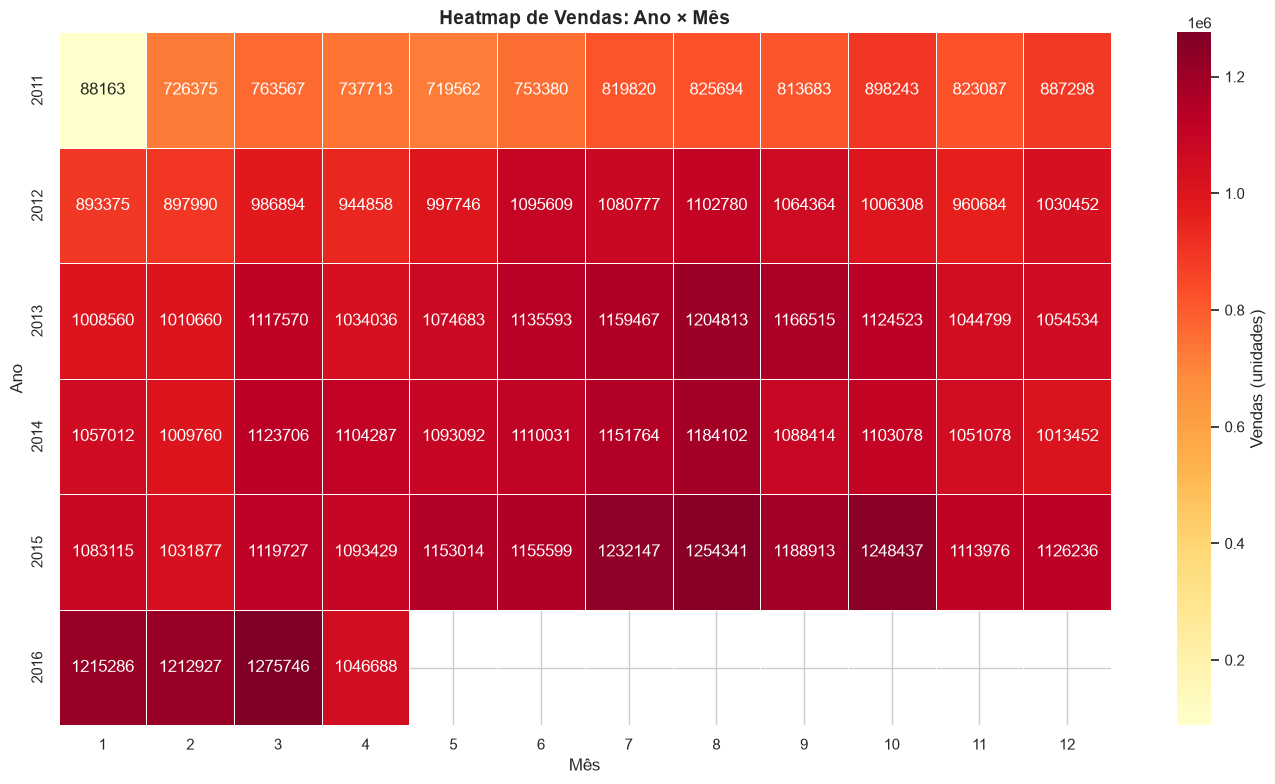

In [15]:
# Criar tabela pivô: anos como linhas, meses como colunas
pivot = df_eda.pivot_table(index=df_eda.index.year, columns='mes', values='vendas')

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Vendas (unidades)'})
ax.set_title('Heatmap de Vendas: Ano × Mês', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Ano')
plt.tight_layout()
plt.show()

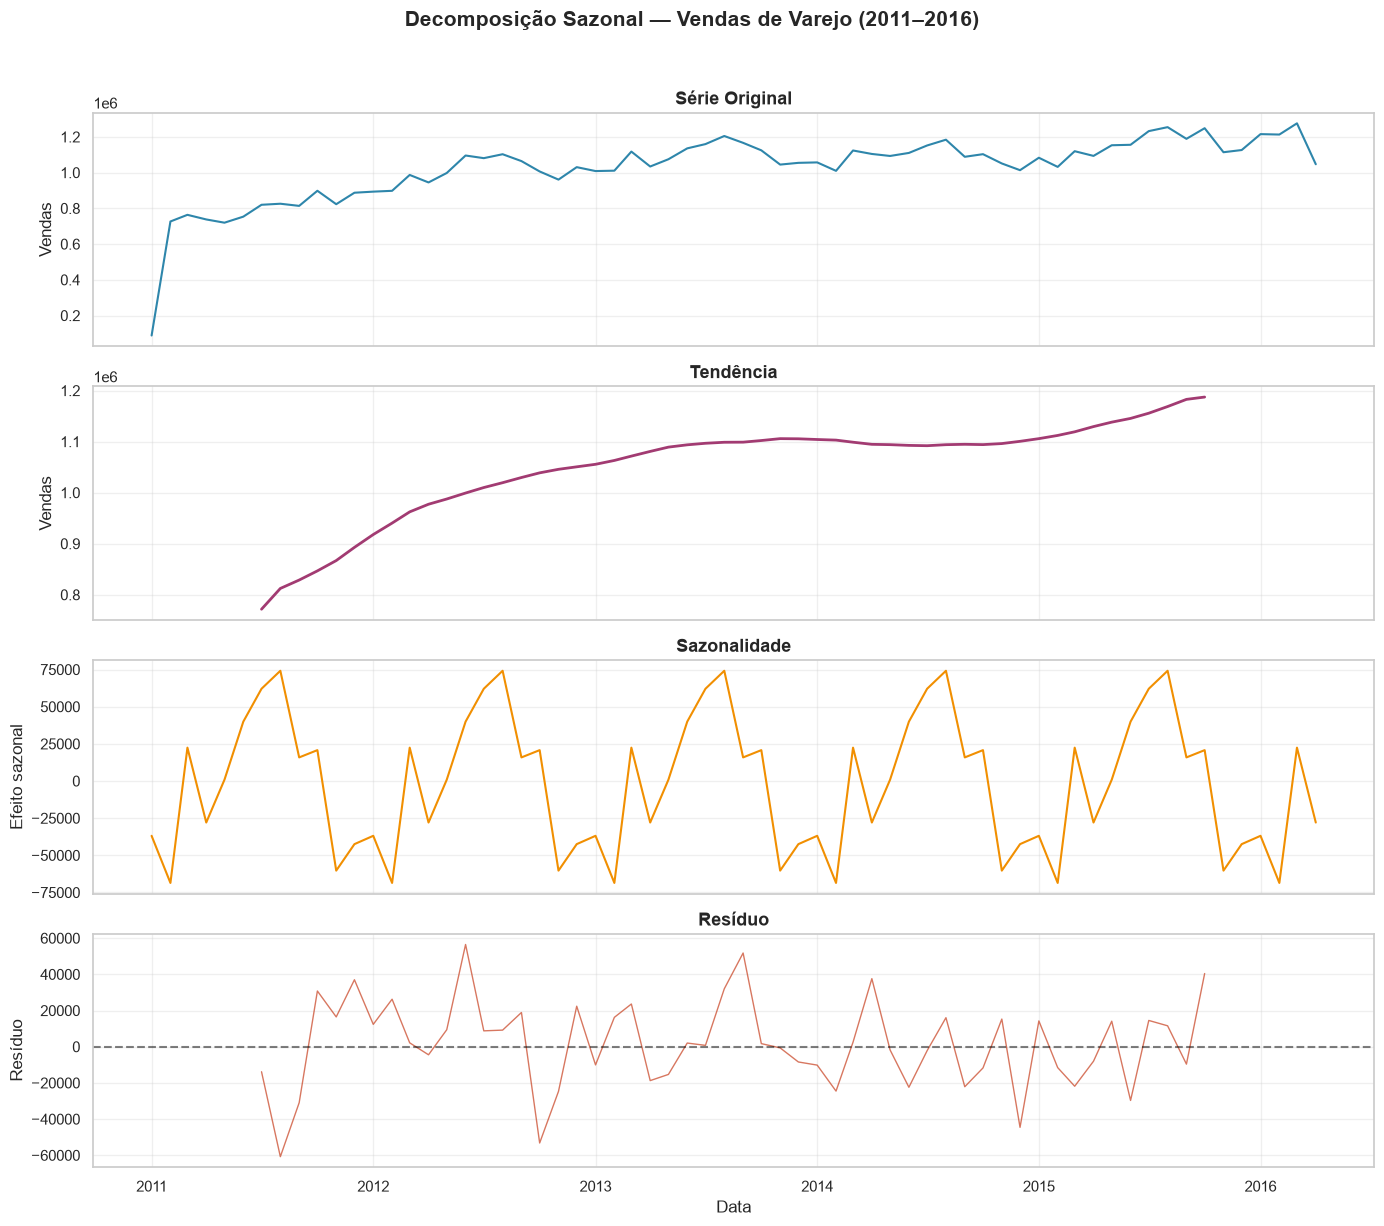

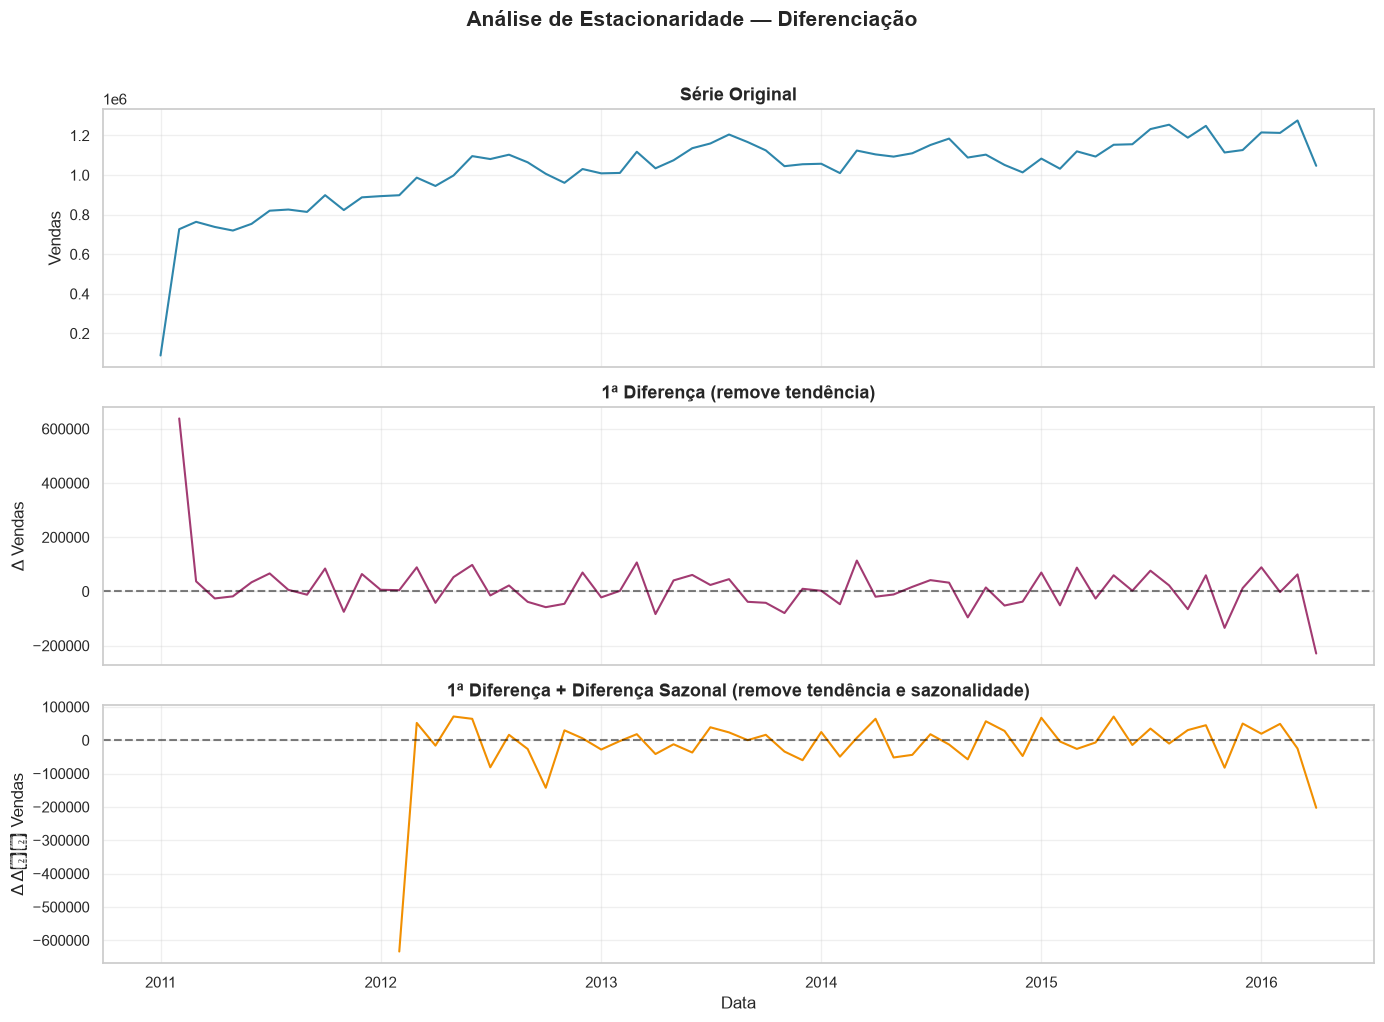

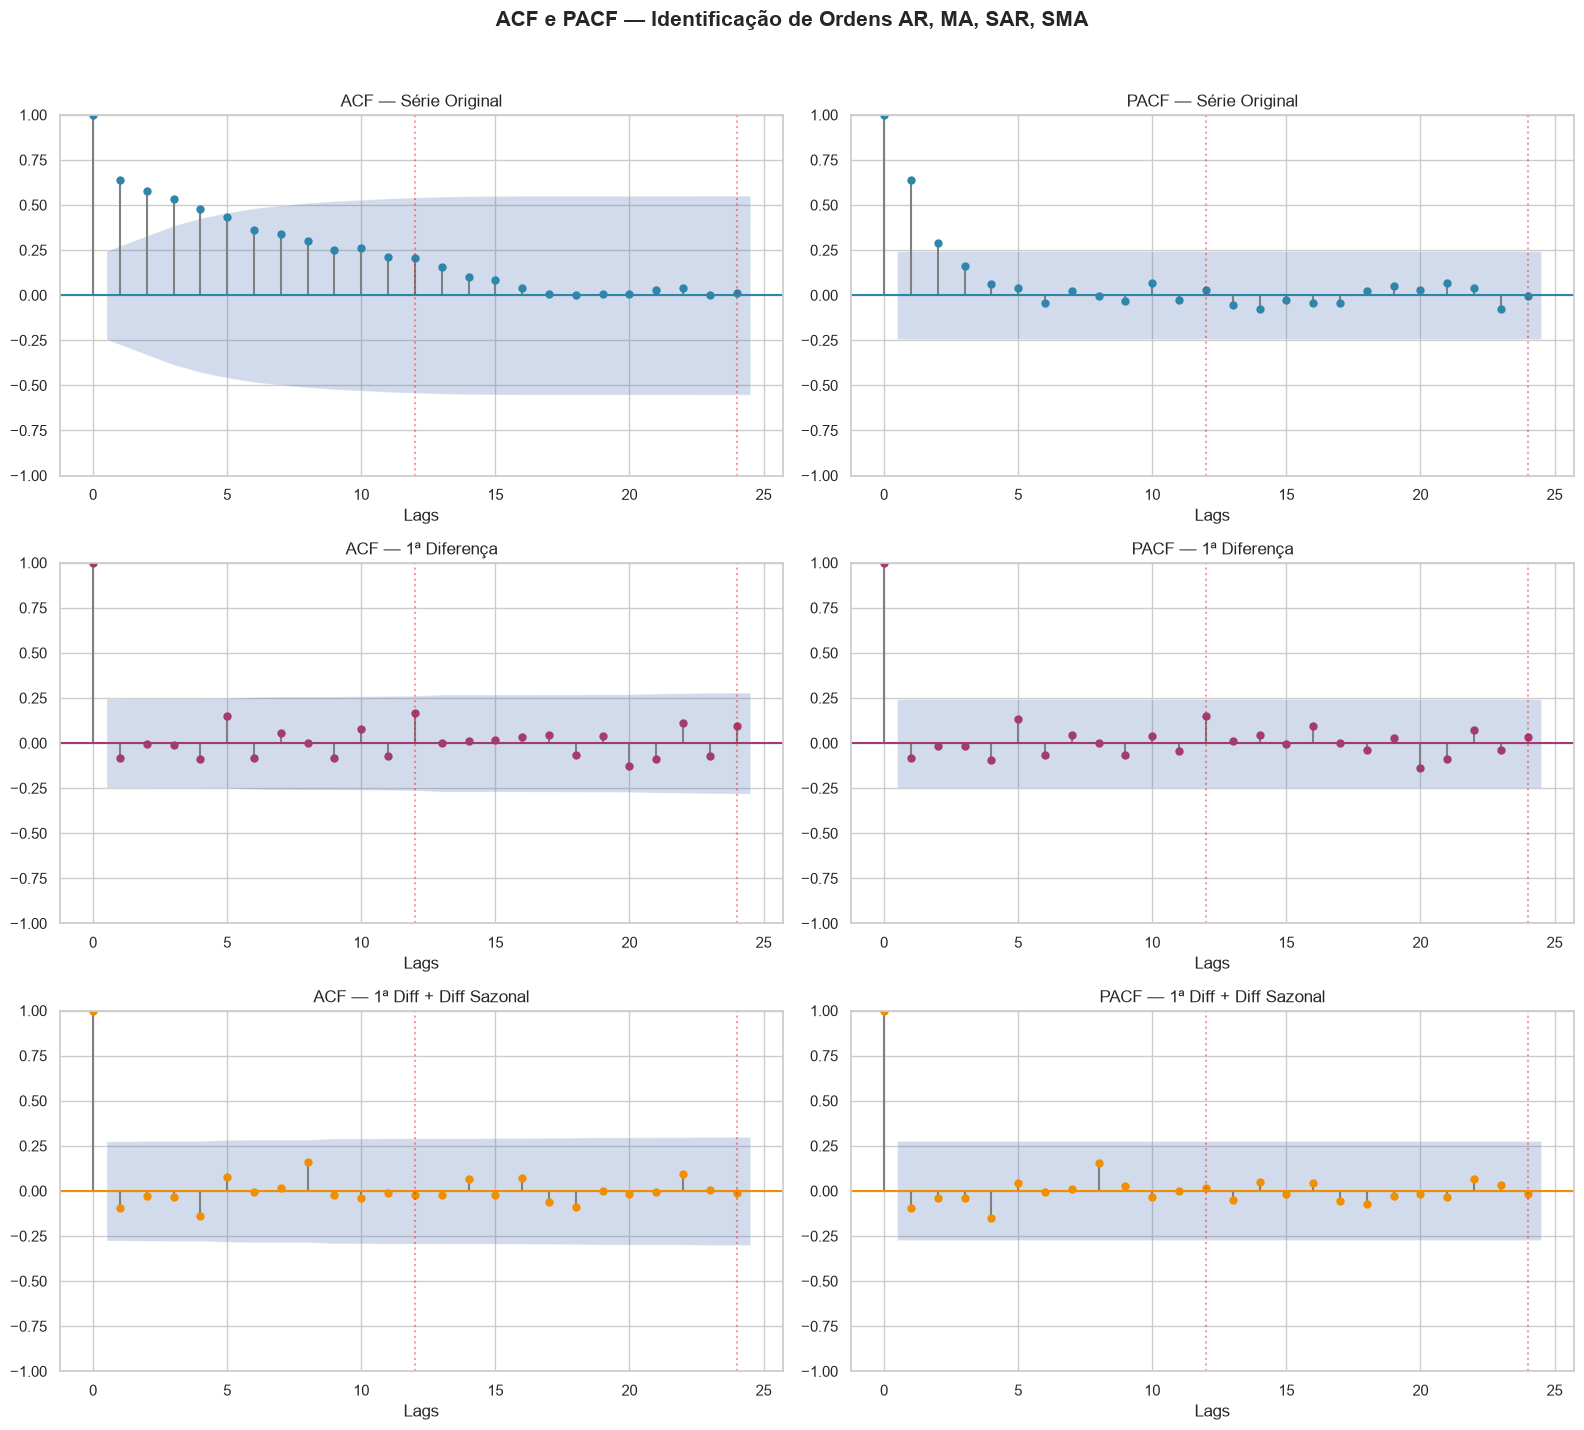


## 📊 Análise Completa da Série Temporal

### Visão Geral

| Métrica | Valor |
|---------|-------|
| **Período** | 2011-01-01 00:00:00a 2016-04-01 00:00:00 (64 observações) |
| **Frequência** | Mensal (`MS`) |
| **Modelo de decomposição** | Aditivo |
| **Variância explicada** | 98.2% |

---

### 1. Tendência

| Métrica | Valor |
|---------|-------|
| **Início (tendência)** | 771,599 unidades/mês |
| **Fim (tendência)** | 1,187,223 unidades/mês |
| **Crescimento linear** | +5638 unidades/ano |
| **Crescimento total (5 anos)** | 53.9% |

A tendência é **linear e crescente**, com crescimento médio de 
**+5638 unidades/ano**. A série passou de aproximadamente 
**771,599** para **1,187,223** unidades/mês, 
um aumento de **53.9%** em 5 anos.

---

### 2. Sazonalidade

| Métrica | Valor |
|---------|-------|
| **Mês de pico** | Agosto (+74,165 unidades acima da média) |
| **Mês de vale** | Fevereiro (-68,577 unidades abaixo da média) |
| **Amplitude sazonal** | 142,742 unidades |

#### Efeito sazonal por mês

| Mês | Efeito sazonal (unidades) |
|-----|--------------------------:|
| Janeiro | -36,873 |
| Fevereiro | -68,577 |
| Março | +22,452 |
| Abril | -27,927 |
| Maio | +877 |
| Junho | +39,932 |
| Julho | +62,062 |
| Agosto | +74,165 |
| Setembro | +15,874 |
| Outubro | +20,771 |
| Novembro | -60,287 |
| Dezembro | -42,470 |

---

### 3. Resíduo

| Métrica | Valor |
|---------|-------|
| **Média** | +1,594.59 |
| **Desvio padrão** | 24,641.12 |
| **Mínimo** | -60,772 |
| **Máximo** | +56,489 |
| **Outliers (resíduo > 2σ)** | 4 |

#### Outliers no resíduo

| Mês/Ano | Resíduo |
|---------|--------:|
| 08/2011 | -60,772 |
| 06/2012 | +56,489 |
| 10/2012 | -53,210 |
| 09/2013 | +51,776 |

---

### 4. Testes de Estacionaridade

#### 4.1 ADF (Augmented Dickey-Fuller)

> **H0**: a série **NÃO é estacionária** (tem raiz unitária)   
> **H1**: a série **É estacionária**  
> **Critério**: p-valor < 0.05 → rejeita H0 → série é estacionária   

| Métrica | Série Original | 1ª Diferença | 1ª Diff + Diff Sazonal |
|---------|---------------:|-------------:|----------------------:|
| **Estatística ADF** | -3.6201 | -2.3088 | -6.0152 |
| **p-valor** | 0.0054 | 0.1691 | 0.0000 |
| **Estacionária?** | ✅ Sim | ❌ Não | ✅ Sim |

#### Valores críticos do ADF (série original)

| Nível de significância | Valor crítico |
|------------------------|--------------:|
| 1% | -3.5629 |
| 5% | -2.9190 |
| 10% | -2.5974 |

#### 4.2 KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

> **H0**: a série **É estacionária**  
> **H1**: a série **NÃO é estacionária**  
> **Critério**: p-valor < 0.05 → rejeita H0 → série NÃO é estacionária  

| Métrica | Valor |
|---------|-------|
| **Estatística KPSS** | 1.0690 |
| **p-valor** | 0.0100 |
| **Estacionária?** | ❌ Não |

#### Valores críticos do KPSS

| Nível de significância | Valor crítico |
|------------------------|--------------:|
| 10% | 0.3470 |
| 5% | 0.4630 |
| 2.5% | 0.5740 |
| 1% | 0.7390 |

#### 4.3 Conclusão sobre estacionaridade

⚠️ **Resultado conflitante** — ADF e KPSS divergem.

| Transformação | ADF p-valor | Estacionária? |
|---------------|-----------:|:-------------:|
| **Série original** | 0.0054 | ✅ Sim |
| **1ª diferença** | 0.1691 | ❌ Não |
| **1ª diff + diff sazonal** | 0.0000 | ✅ Sim |

A série original já é estacionária.

---

### 5. ACF e PACF — Identificação de Ordens SARIMA

#### 5.1 Interpretação visual

Os gráficos de ACF e PACF foram gerados para **3 versões da série**:

| Série | ACF (lags sig. 1-10) | PACF (lags sig. 1-10) | Padrão ACF | Padrão PACF |
|-------|--------------------:|---------------------:|------------|-------------|
| **Original** | 10 | 2 | Decai lentamente | Decai lentamente |
| **1ª Diferença** | 0 | 0 | corta após lag 0 | corta após lag 0 |
| **1ª Diff + Sazonal** | 0 | 0 | corta após lag 0 | corta após lag 0 |

> Linhas vermelhas pontilhadas nos gráficos marcam os **lags sazonais** (12, 24, 36).

#### 5.2 Lags significativos — 1ª Diff + Diff Sazonal (série para modelagem)

| Lag | ACF | PACF |
|----:|-----:|-----:|
| 1 | -0.095 — | -0.095 — |
| 2 | -0.029 — | -0.038 — |
| 3 | -0.032 — | -0.038 — |
| 4 | -0.141 — | -0.151 — |
| 5 | +0.077 — | +0.047 — |
| 6 | -0.004 — | -0.005 — |
| 7 | +0.016 — | +0.008 — |
| 8 | +0.161 — | +0.153 — |
| 9 | -0.025 — | +0.025 — |
| 10 | -0.040 — | -0.032 — |
| **12** (sazonal) | -0.021 — | +0.014 — |
| **24** (sazonal) | -0.011 — | -0.018 — |

#### 5.3 Interpretação automática

| Componente | Padrão observado | Sugestão |
|------------|------------------|----------|
| **ACF** (não sazonal) | ACF corta após lag 0 | q = 1 |
| **PACF** (não sazonal) | PACF corta após lag 0 | p = 1 |
| **ACF sazonal** (lags 12, 24, 36) | Significativos em: nenhum | Q = 0 |
| **PACF sazonal** (lags 12, 24, 36) | Significativos em: nenhum | P = 0 |

#### 5.4 Regras de Box-Jenkins aplicadas

| Padrão ACF | Padrão PACF | Modelo sugerido |
|------------|-------------|-----------------|
| Corta após lag q | Decai (tail-off) | **MA(q)** |
| Decai (tail-off) | Corta após lag p | **AR(p)** |
| Decai (tail-off) | Decai (tail-off) | **ARMA(p, q)** |

---

### 6. Conclusão Geral e Sugestão SARIMA

A análise completa revela:

1. **Tendência linear crescente** de +5638 unidades/ano (53.9% em 15 anos)
2. **Sazonalidade forte e estável** com pico em Agosto e vale em Fevereiro
3. **Amplitude sazonal de 142,742 unidades** entre pico e vale
4. **98.2% da variância** explicada por tendência + sazonalidade
5. **Série não estacionária** na forma original — requer d=1 e D=1
6. **ACF/PACF** sugerem componentes AR e MA tanto na parte regular quanto sazonal

#### Sugestão de parâmetros SARIMA

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| **p** (AR regular) | 1 | PACF pacf corta após lag 0 |
| **d** (diff regular) | 1 | Remove tendência linear |
| **q** (MA regular) | 1 | ACF acf corta após lag 0 |
| **P** (AR sazonal) | 0 | PACF sazonal não significativo |
| **D** (diff sazonal) | 1 | Remove sazonalidade anual |
| **Q** (MA sazonal) | 0 | ACF sazonal não significativo |
| **s** (período) | 12 | Série mensal |

> **Modelo sugerido**: SARIMA(1, 1, 1)×(0, 1, 0)₁₂


In [28]:
# ========================================
# Decomposição
# ========================================

decomposicao = seasonal_decompose(df_eda['vendas'], model='additive', period=12)
tendencia = decomposicao.trend
sazonalidade = decomposicao.seasonal
residuo = decomposicao.resid

# Plotar os dados
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df_eda.index, df_eda['vendas'], color='#2E86AB', linewidth=1.5)
axes[0].set_title('Série Original', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Vendas')
axes[0].grid(True, alpha=0.3)

axes[1].plot(tendencia.index, tendencia, color='#A23B72', linewidth=2)
axes[1].set_title('Tendência', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Vendas')
axes[1].grid(True, alpha=0.3)

axes[2].plot(sazonalidade.index, sazonalidade, color='#F18F01', linewidth=1.5)
axes[2].set_title('Sazonalidade', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Efeito sazonal')
axes[2].grid(True, alpha=0.3)

axes[3].plot(residuo.index, residuo, color='#C73E1D', linewidth=1, alpha=0.7)
axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[3].set_title('Resíduo', fontsize=13, fontweight='bold')
axes[3].set_ylabel('Resíduo')
axes[3].set_xlabel('Data')
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'Decomposição Sazonal — Vendas de Varejo ({df.index.min().year}–{df.index.max().year})',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========================================
# Teste de Estacionaridade
# ========================================

# ADF
adf_result = adfuller(df_eda['vendas'].dropna())
adf_stat = adf_result[0]
adf_pvalue = adf_result[1]
adf_crit = adf_result[4]

# KPSS
kpss_result = kpss(df_eda['vendas'].dropna(), regression='c')
kpss_stat = kpss_result[0]
kpss_pvalue = kpss_result[1]
kpss_crit = kpss_result[3]

# Diferenciação
df_diff1 = df_eda['vendas'].diff().dropna()
adf_diff1 = adfuller(df_diff1)
adf_diff1_stat = adf_diff1[0]
adf_diff1_pvalue = adf_diff1[1]

df_diff_seasonal = df_eda['vendas'].diff().diff(12).dropna()
adf_diff_s = adfuller(df_diff_seasonal)
adf_diff_s_stat = adf_diff_s[0]
adf_diff_s_pvalue = adf_diff_s[1]

# Plotar série original vs diferenciadas
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['vendas'], color='#2E86AB', linewidth=1.5)
axes[0].set_title('Série Original', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Vendas')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_diff1.index, df_diff1, color='#A23B72', linewidth=1.5)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('1ª Diferença (remove tendência)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Δ Vendas')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_diff_seasonal.index, df_diff_seasonal, color='#F18F01', linewidth=1.5)
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[2].set_title('1ª Diferença + Diferença Sazonal (remove tendência e sazonalidade)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Δ Δ₁₂ Vendas')
axes[2].set_xlabel('Data')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Análise de Estacionaridade — Diferenciação',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========================================
# ACF e PACF
# ========================================

# Calcular ACF e PACF para as 3 versões da série
nlags = 24  # 2 ciclos sazonais (2 x 12)

# Série original
acf_orig = acf(df_eda['vendas'].dropna(), nlags=nlags)
pacf_orig = pacf(df_eda['vendas'].dropna(), nlags=nlags, method='ywm')

# 1ª diferença
acf_diff1 = acf(df_diff1, nlags=nlags)
pacf_diff1 = pacf(df_diff1, nlags=nlags, method='ywm')

# 1ª diff + diff sazonal
acf_diff_s = acf(df_diff_seasonal, nlags=nlags)
pacf_diff_s = pacf(df_diff_seasonal, nlags=nlags, method='ywm')

# Intervalo de confiança (95%)
conf_int = 1.96 / np.sqrt(len(df['vendas'].dropna()))

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Série Original
plot_acf(df_eda['vendas'].dropna(), lags=nlags, ax=axes[0, 0], alpha=0.05,
         title='ACF — Série Original', color='#2E86AB', vlines_kwargs={'colors': 'gray'})
axes[0, 0].set_xlabel('Lags')
plot_pacf(df_eda['vendas'].dropna(), lags=nlags, ax=axes[0, 1], alpha=0.05,
          title='PACF — Série Original', color='#2E86AB', method='ywm', vlines_kwargs={'colors': 'gray'})
axes[0, 1].set_xlabel('Lags')

# 1ª Diferença
plot_acf(df_diff1, lags=nlags, ax=axes[1, 0], alpha=0.05,
         title='ACF — 1ª Diferença', color='#A23B72', vlines_kwargs={'colors': 'gray'})
axes[1, 0].set_xlabel('Lags')
plot_pacf(df_diff1, lags=nlags, ax=axes[1, 1], alpha=0.05,
          title='PACF — 1ª Diferença', color='#A23B72', method='ywm', vlines_kwargs={'colors': 'gray'})
axes[1, 1].set_xlabel('Lags')

# 1ª Diff + Diff Sazonal
plot_acf(df_diff_seasonal, lags=nlags, ax=axes[2, 0], alpha=0.05,
         title='ACF — 1ª Diff + Diff Sazonal', color='#F18F01', vlines_kwargs={'colors': 'gray'})
axes[2, 0].set_xlabel('Lags')
plot_pacf(df_diff_seasonal, lags=nlags, ax=axes[2, 1], alpha=0.05,
          title='PACF — 1ª Diff + Diff Sazonal', color='#F18F01', method='ywm', vlines_kwargs={'colors': 'gray'})
axes[2, 1].set_xlabel('Lags')

# Marcar lags sazonais (12, 24, 36)
for i in range(3):
    for j in range(2):
        for lag_sazonal in [12, 24, 36]:
            if lag_sazonal <= nlags:
                axes[i, j].axvline(x=lag_sazonal, color='red', linestyle=':', alpha=0.4)

plt.suptitle('ACF e PACF — Identificação de Ordens AR, MA, SAR, SMA',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========================================
# Interpretação do ACF/PACF
# ========================================
interp_orig = interpretar_acf_pacf(acf_orig, pacf_orig, conf_int, 'Série Original')
interp_diff1 = interpretar_acf_pacf(acf_diff1, pacf_diff1, conf_int, '1ª Diferença')
interp_diff_s = interpretar_acf_pacf(acf_diff_s, pacf_diff_s, conf_int, '1ª Diff + Diff Sazonal')

q_sugerido = interp_diff_s['corte_acf'] if interp_diff_s['corte_acf'] > 0 and not interp_diff_s['acf_tail_off'] else 1
p_sugerido = interp_diff_s['corte_pacf'] if interp_diff_s['corte_pacf'] > 0 and not interp_diff_s['pacf_tail_off'] else 1

# Ordens sazonais (P, Q) baseadas nos lags 12, 24, 36
Q_sugerido = 1 if len(interp_diff_s['lags_sazonais_acf']) > 0 else 0
P_sugerido = 1 if len(interp_diff_s['lags_sazonais_pacf']) > 0 else 0

# ========================================
# Parâmetros para o Resumo
# ========================================

# Tendência
tendencia_limpa = tendencia.dropna()
val_ini_tend = tendencia_limpa.iloc[0]
val_fim_tend = tendencia_limpa.iloc[-1]
crescimento_total = ((val_fim_tend / val_ini_tend) - 1) * 100

x = np.arange(len(tendencia_limpa))
z = np.polyfit(x, tendencia_limpa.values, 1)
crescimento_ano = z[0]

# Sazonalidade
sazonal_mensal = sazonalidade.groupby(sazonalidade.index.month).mean()
mes_pico = sazonal_mensal.idxmax()
val_pico = sazonal_mensal.max()
mes_vale = sazonal_mensal.idxmin()
val_vale = sazonal_mensal.min()
amplitude = val_pico - val_vale

nomes_meses = {1:'Janeiro', 2:'Fevereiro', 3:'Março', 4:'Abril', 5:'Maio',
               6:'Junho', 7:'Julho', 8:'Agosto', 9:'Setembro', 10:'Outubro',
               11:'Novembro', 12:'Dezembro'}

# Resíduo
residuo_limpo = residuo.dropna()
media_resid = residuo_limpo.mean()
std_resid = residuo_limpo.std()
max_resid = residuo_limpo.max()
min_resid = residuo_limpo.min()
outliers = residuo_limpo[np.abs(residuo_limpo) > 2 * std_resid]

# Variância explicada
var_total = df_eda['vendas'].var()
var_resid = residuo_limpo.var()
pct_explicada = ((var_total - var_resid) / var_total) * 100

# Estacionaridade
adf_estacionaria = adf_pvalue < 0.05
kpss_estacionaria = kpss_pvalue > 0.05

if adf_estacionaria and kpss_estacionaria:
    conclusao_estac = "✅ **Série estacionária** — ambos os testes concordam."
elif not adf_estacionaria and not kpss_estacionaria:
    conclusao_estac = "❌ **Série NÃO estacionária** — ambos os testes concordam."
else:
    conclusao_estac = "⚠️ **Resultado conflitante** — ADF e KPSS divergem."

diff1_estac = adf_diff1_pvalue < 0.05
diff_s_estac = adf_diff_s_pvalue < 0.05

# ========================================
# Resumo
# ========================================

# Tabela de efeitos sazonais por mês
linhas_sazonal = "\n".join(
    f"| {nomes_meses[m]} | {sazonal_mensal[m]:+,.0f} |"
    for m in sorted(sazonal_mensal.index)
)

# Tabela de outliers no resíduo
if len(outliers) > 0:
    linhas_outliers = "\n".join(
        f"| {idx.strftime('%m/%Y')} | {val:+,.0f} |"
        for idx, val in outliers.items()
    )
else:
    linhas_outliers = "| — | — |"

# Tabela de testes de estacionaridade
linhas_adf_crit = "\n".join(
    f"| {k} | {v:.4f} |" for k, v in adf_crit.items()
)
linhas_kpss_crit = "\n".join(
    f"| {k} | {v:.4f} |" for k, v in kpss_crit.items()
)

# Tabela ACF/PACF — série diferenciada
tabela_lags = tabela_lags_significativos(interp_diff_s, conf_int)

# Interpretação do ACF/PACF
interp_acf_texto = (
    f"ACF corta após lag {interp_diff_s['corte_acf']}" if not interp_diff_s['acf_tail_off']
    else "ACF decai gradualmente (tail-off)"
)
interp_pacf_texto = (
    f"PACF corta após lag {interp_diff_s['corte_pacf']}" if not interp_diff_s['pacf_tail_off']
    else "PACF decai gradualmente (tail-off)"
)

# Lags sazonais
sazonal_acf_txt = ", ".join(str(l) for l in interp_diff_s['lags_sazonais_acf']) if interp_diff_s['lags_sazonais_acf'] else "nenhum"
sazonal_pacf_txt = ", ".join(str(l) for l in interp_diff_s['lags_sazonais_pacf']) if interp_diff_s['lags_sazonais_pacf'] else "nenhum"

display(Markdown(f"""
## 📊 Análise Completa da Série Temporal

### Visão Geral

| Métrica | Valor |
|---------|-------|
| **Período** | {df.index.min()}a {df.index.max()} ({len(df)} observações) |
| **Frequência** | Mensal (`MS`) |
| **Modelo de decomposição** | Aditivo |
| **Variância explicada** | {pct_explicada:.1f}% |

---

### 1. Tendência

| Métrica | Valor |
|---------|-------|
| **Início (tendência)** | {val_ini_tend:,.0f} unidades/mês |
| **Fim (tendência)** | {val_fim_tend:,.0f} unidades/mês |
| **Crescimento linear** | +{crescimento_ano:.0f} unidades/ano |
| **Crescimento total ({df.index.max().year - df.index.min().year} anos)** | {crescimento_total:.1f}% |

A tendência é **linear e crescente**, com crescimento médio de 
**+{crescimento_ano:.0f} unidades/ano**. A série passou de aproximadamente 
**{val_ini_tend:,.0f}** para **{val_fim_tend:,.0f}** unidades/mês, 
um aumento de **{crescimento_total:.1f}%** em {df.index.max().year - df.index.min().year} anos.

---

### 2. Sazonalidade

| Métrica | Valor |
|---------|-------|
| **Mês de pico** | {nomes_meses[mes_pico]} ({val_pico:+,.0f} unidades acima da média) |
| **Mês de vale** | {nomes_meses[mes_vale]} ({val_vale:+,.0f} unidades abaixo da média) |
| **Amplitude sazonal** | {amplitude:,.0f} unidades |

#### Efeito sazonal por mês

| Mês | Efeito sazonal (unidades) |
|-----|--------------------------:|
{linhas_sazonal}

---

### 3. Resíduo

| Métrica | Valor |
|---------|-------|
| **Média** | {media_resid:+,.2f} |
| **Desvio padrão** | {std_resid:,.2f} |
| **Mínimo** | {min_resid:+,.0f} |
| **Máximo** | {max_resid:+,.0f} |
| **Outliers (resíduo > 2σ)** | {len(outliers)} |

#### Outliers no resíduo

| Mês/Ano | Resíduo |
|---------|--------:|
{linhas_outliers}

---

### 4. Testes de Estacionaridade

#### 4.1 ADF (Augmented Dickey-Fuller)

> **H0**: a série **NÃO é estacionária** (tem raiz unitária)   
> **H1**: a série **É estacionária**  
> **Critério**: p-valor < 0.05 → rejeita H0 → série é estacionária   

| Métrica | Série Original | 1ª Diferença | 1ª Diff + Diff Sazonal |
|---------|---------------:|-------------:|----------------------:|
| **Estatística ADF** | {adf_stat:.4f} | {adf_diff1_stat:.4f} | {adf_diff_s_stat:.4f} |
| **p-valor** | {adf_pvalue:.4f} | {adf_diff1_pvalue:.4f} | {adf_diff_s_pvalue:.4f} |
| **Estacionária?** | {'✅ Sim' if adf_estacionaria else '❌ Não'} | {'✅ Sim' if diff1_estac else '❌ Não'} | {'✅ Sim' if diff_s_estac else '❌ Não'} |

#### Valores críticos do ADF (série original)

| Nível de significância | Valor crítico |
|------------------------|--------------:|
{linhas_adf_crit}

#### 4.2 KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

> **H0**: a série **É estacionária**  
> **H1**: a série **NÃO é estacionária**  
> **Critério**: p-valor < 0.05 → rejeita H0 → série NÃO é estacionária  

| Métrica | Valor |
|---------|-------|
| **Estatística KPSS** | {kpss_stat:.4f} |
| **p-valor** | {kpss_pvalue:.4f} |
| **Estacionária?** | {'✅ Sim' if kpss_estacionaria else '❌ Não'} |

#### Valores críticos do KPSS

| Nível de significância | Valor crítico |
|------------------------|--------------:|
{linhas_kpss_crit}

#### 4.3 Conclusão sobre estacionaridade

{conclusao_estac}

| Transformação | ADF p-valor | Estacionária? |
|---------------|-----------:|:-------------:|
| **Série original** | {adf_pvalue:.4f} | {'❌ Não' if not adf_estacionaria else '✅ Sim'} |
| **1ª diferença** | {adf_diff1_pvalue:.4f} | {'✅ Sim' if diff1_estac else '❌ Não'} |
| **1ª diff + diff sazonal** | {adf_diff_s_pvalue:.4f} | {'✅ Sim' if diff_s_estac else '❌ Não'} |

{"A série original **não é estacionária** (presença de tendência e sazonalidade). A **1ª diferença** já remove a tendência. A **1ª diferença + diferença sazonal** remove tanto tendência quanto sazonalidade, tornando a série estacionária." if not adf_estacionaria else "A série original já é estacionária."}

---

### 5. ACF e PACF — Identificação de Ordens SARIMA

#### 5.1 Interpretação visual

Os gráficos de ACF e PACF foram gerados para **3 versões da série**:

| Série | ACF (lags sig. 1-10) | PACF (lags sig. 1-10) | Padrão ACF | Padrão PACF |
|-------|--------------------:|---------------------:|------------|-------------|
| **Original** | {interp_orig['qtd_acf_sig']} | {interp_orig['qtd_pacf_sig']} | Decai lentamente | Decai lentamente |
| **1ª Diferença** | {interp_diff1['qtd_acf_sig']} | {interp_diff1['qtd_pacf_sig']} | {interp_acf_texto.replace('ACF ', '')} | {interp_pacf_texto.replace('PACF ', '')} |
| **1ª Diff + Sazonal** | {interp_diff_s['qtd_acf_sig']} | {interp_diff_s['qtd_pacf_sig']} | {interp_acf_texto.replace('ACF ', '')} | {interp_pacf_texto.replace('PACF ', '')} |

> Linhas vermelhas pontilhadas nos gráficos marcam os **lags sazonais** (12, 24, 36).

#### 5.2 Lags significativos — 1ª Diff + Diff Sazonal (série para modelagem)

| Lag | ACF | PACF |
|----:|-----:|-----:|
{tabela_lags}

#### 5.3 Interpretação automática

| Componente | Padrão observado | Sugestão |
|------------|------------------|----------|
| **ACF** (não sazonal) | {interp_acf_texto} | q = {q_sugerido} |
| **PACF** (não sazonal) | {interp_pacf_texto} | p = {p_sugerido} |
| **ACF sazonal** (lags 12, 24, 36) | Significativos em: {sazonal_acf_txt} | Q = {Q_sugerido} |
| **PACF sazonal** (lags 12, 24, 36) | Significativos em: {sazonal_pacf_txt} | P = {P_sugerido} |

#### 5.4 Regras de Box-Jenkins aplicadas

| Padrão ACF | Padrão PACF | Modelo sugerido |
|------------|-------------|-----------------|
| Corta após lag q | Decai (tail-off) | **MA(q)** |
| Decai (tail-off) | Corta após lag p | **AR(p)** |
| Decai (tail-off) | Decai (tail-off) | **ARMA(p, q)** |

---

### 6. Conclusão Geral e Sugestão SARIMA

A análise completa revela:

1. **Tendência linear crescente** de +{crescimento_ano:.0f} unidades/ano ({crescimento_total:.1f}% em 15 anos)
2. **Sazonalidade forte e estável** com pico em {nomes_meses[mes_pico]} e vale em {nomes_meses[mes_vale]}
3. **Amplitude sazonal de {amplitude:,.0f} unidades** entre pico e vale
4. **{pct_explicada:.1f}% da variância** explicada por tendência + sazonalidade
5. **Série não estacionária** na forma original — requer d=1 e D=1
6. **ACF/PACF** sugerem componentes AR e MA tanto na parte regular quanto sazonal

#### Sugestão de parâmetros SARIMA

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| **p** (AR regular) | {p_sugerido} | PACF {interp_pacf_texto.lower()} |
| **d** (diff regular) | 1 | Remove tendência linear |
| **q** (MA regular) | {q_sugerido} | ACF {interp_acf_texto.lower()} |
| **P** (AR sazonal) | {P_sugerido} | PACF sazonal {"significativo" if P_sugerido > 0 else "não significativo"} |
| **D** (diff sazonal) | 1 | Remove sazonalidade anual |
| **Q** (MA sazonal) | {Q_sugerido} | ACF sazonal {"significativo" if Q_sugerido > 0 else "não significativo"} |
| **s** (período) | 12 | Série mensal |

> **Modelo sugerido**: SARIMA({p_sugerido}, 1, {q_sugerido})×({P_sugerido}, 1, {Q_sugerido})₁₂
"""))

## 5. Geração do Modelo Preditivo

Feita toda as análises preliminares, passamos a identificar o melhor modelo preditivo

In [ ]:
# ========================================
# Separar treino e teste
# ========================================
# usaremos 20% da quantidade de anos na base para teste
qtd_anos = df.index.year.max() - df.index.year.min() + 1

n_teste = 12 * int(qtd_anos * 0.2)
treino = df_eda['vendas'].iloc[:-n_teste]
teste = df_eda['vendas'].iloc[-n_teste:]

print(f"Treino: {treino.index[0].strftime('%m/%Y')} a {treino.index[-1].strftime('%m/%Y')} ({len(treino)} obs)")
print(f"Teste:  {teste.index[0].strftime('%m/%Y')} a {teste.index[-1].strftime('%m/%Y')} ({len(teste)} obs)")

# ========================================
# MODELO 1: SARIMA (parâmetros sugeridos)
# ========================================

modelo_sarima = SARIMAX(
    treino,
    order=(p_sugerido, 1, q_sugerido),
    seasonal_order=(P_sugerido, 1, Q_sugerido, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)

prev_sarima = resultado_sarima.get_forecast(steps=n_teste)
prev_sarima_mean = prev_sarima.predicted_mean
prev_sarima_conf = prev_sarima.conf_int(alpha=0.05)

# ========================================
# MODELO 2: HOLT-WINTERS (Exponential Smoothing)
# ========================================

modelo_hw = ExponentialSmoothing(
    treino,
    trend='add',
    seasonal='add',
    seasonal_periods=12,
    initialization_method='estimated'
)
resultado_hw = modelo_hw.fit()

prev_hw = resultado_hw.forecast(steps=n_teste)
# Intervalo de confiança aproximado (Holt-Winters não tem IC nativo)
residuos_hw = treino - resultado_hw.fittedvalues
desvio_hw = residuos_hw.std()
ic_hw_lower = prev_hw - 1.96 * desvio_hw
ic_hw_upper = prev_hw + 1.96 * desvio_hw

# ========================================
# MODELO 3: PROPHET
# ========================================
# Preparar dados no formato do Prophet (ds, y)
df_prophet = pd.DataFrame({
    'ds': treino.index,
    'y': treino.values
})

modelo_prophet = Prophet(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
modelo_prophet.fit(df_prophet)

# Previsão
futuro = modelo_prophet.make_future_dataframe(periods=n_teste, freq='MS')
previsao_prophet = modelo_prophet.predict(futuro)

prev_prophet = previsao_prophet.iloc[-n_teste:]['yhat'].values
prev_prophet_lower = previsao_prophet.iloc[-n_teste:]['yhat_lower'].values
prev_prophet_upper = previsao_prophet.iloc[-n_teste:]['yhat_upper'].values
prev_prophet_idx = teste.index

# ========================================
# MÉTRICAS DE ERRO
# ========================================
metricas_sarima = calcular_metricas(teste.values, prev_sarima_mean.values)
metricas_hw = calcular_metricas(teste.values, prev_hw.values)
metricas_prophet = calcular_metricas(teste.values, prev_prophet)

# ========================================
# COMPARAÇÃO
# ========================================

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- Gráfico 1: Série completa ---
ax = axes[0]
ax.plot(df.index, df['vendas'], color='#2E86AB', linewidth=1.5, label='Histórico', alpha=0.7)
ax.plot(teste.index, teste, color='black', linewidth=2.5, marker='o', label='Real (teste)', markersize=6)

# SARIMA
ax.plot(prev_sarima_mean.index, prev_sarima_mean, color='#A23B72', linewidth=2,
        marker='s', label='SARIMA', markersize=6)
ax.fill_between(prev_sarima_conf.index, prev_sarima_conf.iloc[:, 0],
                prev_sarima_conf.iloc[:, 1], color='#A23B72', alpha=0.15)

# Holt-Winters
ax.plot(prev_hw.index, prev_hw, color='#F18F01', linewidth=2,
        marker='^', label='Holt-Winters', markersize=6)
ax.fill_between(ic_hw_lower.index, ic_hw_lower, ic_hw_upper, color='#F18F01', alpha=0.15)

# Prophet
ax.plot(prev_prophet_idx, prev_prophet, color='#2ECC71', linewidth=2,
        marker='D', label='Prophet', markersize=6)
ax.fill_between(prev_prophet_idx, prev_prophet_lower, prev_prophet_upper, color='#2ECC71', alpha=0.15)

ax.axvline(x=teste.index[0], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Benchmarking de Modelos — Série Completa', fontsize=14, fontweight='bold')
ax.set_ylabel('Vendas')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# --- Gráfico 2: Zoom no hold-out ---
ax = axes[1]
ax.plot(teste.index, teste, color='black', linewidth=3, marker='o', label='Real', markersize=10)

ax.plot(prev_sarima_mean.index, prev_sarima_mean, color='#A23B72', linewidth=2,
        marker='s', label='SARIMA', markersize=8)
ax.fill_between(prev_sarima_conf.index, prev_sarima_conf.iloc[:, 0],
                prev_sarima_conf.iloc[:, 1], color='#A23B72', alpha=0.2)

ax.plot(prev_hw.index, prev_hw, color='#F18F01', linewidth=2,
        marker='^', label='Holt-Winters', markersize=8)
ax.fill_between(ic_hw_lower.index, ic_hw_lower, ic_hw_upper, color='#F18F01', alpha=0.2)

ax.plot(prev_prophet_idx, prev_prophet, color='#2ECC71', linewidth=2,
        marker='D', label='Prophet', markersize=8)
ax.fill_between(prev_prophet_idx, prev_prophet_lower, prev_prophet_upper, color='#2ECC71', alpha=0.2)

ax.set_title('Zoom — Hold-out 12 meses', fontsize=14, fontweight='bold')
ax.set_ylabel('Vendas')
ax.set_xlabel('Data')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Benchmarking: SARIMA vs Holt-Winters vs Prophet',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ========================================
# TABELA DE PREVISÕES
# ========================================

linhas_prev = ""
for i in range(n_teste):
    linha = f"| {teste.index[i].strftime('%m/%Y')} | {teste.iloc[i]:,} | {prev_sarima_mean.iloc[i]:,.0f} | {prev_hw.iloc[i]:,.0f}"
    linha += f" | {prev_prophet[i]:,.0f} |"
    linha += " |"
    linhas_prev += linha + "\n"

# Determinar melhor modelo por RMSE
modelos_rmse = {
    'SARIMA': metricas_sarima['RMSE'],
    'Holt-Winters': metricas_hw['RMSE'],
}
modelos_rmse['Prophet'] = metricas_prophet['RMSE']

melhor_modelo = min(modelos_rmse, key=modelos_rmse.get)

# Coluna Prophet no header
header_prophet = " | Prophet" 
header_prophet_sep = " |--------:" 

display(Markdown(f"""
## 📊 Benchmarking de Modelos de Previsão

### Modelos Comparados

| Modelo | Tipo | Características |
|--------|------|-----------------|
| **SARIMA({p_sugerido},1,{q_sugerido})({P_sugerido},1,{Q_sugerido})₁₂** | Box-Jenkins | Captura AR, MA, diferenciação e sazonalidade |
| **Holt-Winters** | Exponential Smoothing | Suavização exponencial com tendência e sazonalidade aditivas |
| **Prophet** | Facebook | Modelo aditivo com decomposição de tendência + sazonalidade + feriados |

---

### Previsões vs Real (Hold-out {n_teste} meses)

| Mês | Real | SARIMA | Holt-Winters{header_prophet} |
|-----|-----:|-------:|------------:{header_prophet_sep}
{linhas_prev}

---

### Métricas de Erro

| Métrica | SARIMA | Holt-Winter| Prophet | Melhor |
|---------|-------:|------------:| -------:|--------|
| **MAE** | {metricas_sarima['MAE']:,.2f} | {metricas_hw['MAE']:,.2f} | {metricas_prophet['MAE']:,.2f} | {melhor_modelo} |
| **RMSE** | {metricas_sarima['RMSE']:,.2f} | {metricas_hw['RMSE']:,.2f} | {metricas_prophet['RMSE']:,.2f} | {melhor_modelo} |
| **MAPE** | {metricas_sarima['MAPE']:.2f}% | {metricas_hw['MAPE']:.2f}% | {metricas_prophet['MAPE']:.2f}% | {melhor_modelo} |
| **sMAPE** | {metricas_sarima['sMAPE']:.2f}% | {metricas_hw['sMAPE']:.2f}% | {metricas_prophet['sMAPE']:.2f}% | {melhor_modelo} |

---

### Critérios de Informação

| Modelo | AIC | BIC |
|--------|----:|----:|
| **SARIMA** | {resultado_sarima.aic:.2f} | {resultado_sarima.bic:.2f} |
| **Holt-Winters** | {resultado_hw.aic:.2f} | {resultado_hw.bic:.2f} |
| **Prophet** | N/A | N/A |

> Prophet não usa AIC/BIC — utiliza MAPA (Maximum A Posteriori) para otimização.

---

### Conclusão do Benchmarking

O modelo **{melhor_modelo}** apresentou o **menor RMSE** ({modelos_rmse[melhor_modelo]:,.2f}) 
no hold-out de {n_teste} meses.

O **Prophet** tende a ser mais flexível para séries com mudanças de tendência e feriados, mas pode ser menos preciso que SARIMA em séries com padrões sazonais estáveis.

"""))

In [ ]:
print("=" * 60)
print(f"MELHOR MODELO: {melhor_modelo} (RMSE = {modelos_rmse[melhor_modelo]:,.2f})")
print("=" * 60)

# ========================================
# GERAR PREVISÃO COM O MELHOR MODELO
# ========================================

if melhor_modelo == 'SARIMA':
    modelo_final = SARIMAX(
        df_eda['vendas'],
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    resultado_final = modelo_final.fit(disp=False)
    previsao = resultado_final.get_forecast(steps=12)
    prev_mean = previsao.predicted_mean
    prev_conf = previsao.conf_int(alpha=0.20)

elif melhor_modelo == 'Holt-Winters':
    modelo_final = ExponentialSmoothing(
        df_eda['vendas'],
        trend='add',
        seasonal='add',
        seasonal_periods=12,
        initialization_method='estimated'
    )
    resultado_final = modelo_final.fit()
    prev_mean = resultado_final.forecast(steps=12)
    residuos_hw = df['vendas'] - resultado_final.fittedvalues
    desvio_hw = residuos_hw.std()
    z_80 = 1.282
    prev_conf = pd.DataFrame({
        'lower': prev_mean - z_80 * desvio_hw,
        'upper': prev_mean + z_80 * desvio_hw
    }, index=prev_mean.index)

elif melhor_modelo == 'Prophet':
    df_prophet_full = pd.DataFrame({
        'ds': df_eda.index,
        'y': df_eda['vendas'].values
    })
    modelo_final = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )
    modelo_final.fit(df_prophet_full)
    futuro = modelo_final.make_future_dataframe(periods=12, freq='MS')
    previsao_prophet = modelo_final.predict(futuro)
    prev_mean = pd.Series(
        previsao_prophet.iloc[-12:]['yhat'].values,
        index=pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
    )
    prev_conf = pd.DataFrame({
        'lower': previsao_prophet.iloc[-12:]['yhat_lower'].values,
        'upper': previsao_prophet.iloc[-12:]['yhat_upper'].values
    }, index=prev_mean.index)

# ========================================
# PLANO DE COMPRAS
# ========================================

nomes_meses = {1:'Janeiro', 2:'Fevereiro', 3:'Março', 4:'Abril', 5:'Maio',
               6:'Junho', 7:'Julho', 8:'Agosto', 9:'Setembro', 10:'Outubro',
               11:'Novembro', 12:'Dezembro'}

sazonal_mensal = decomposicao.seasonal.groupby(decomposicao.seasonal.index.month).mean()

print(f"\nPLANO DE COMPRAS — PRÓXIMOS 12 MESES ({melhor_modelo})")
print(f"{'Mês':<12} {'Previsão':>10} {'Mín 80%':>10} {'Máx 80%':>10} {'Buffer':>8} {'Sugestão':>12}")
print("-" * 66)

linhas_compras = []
for i in range(12):
    data = prev_mean.index[i]
    mes = data.month
    prev = prev_mean.iloc[i]
    minimo = prev_conf.iloc[i, 0]
    maximo = prev_conf.iloc[i, 1]
    buffer_pct = 10 if sazonal_mensal[mes] > 0 else 5
    buffer = 1 + buffer_pct / 100
    sugestao = prev * buffer
    print(f"{nomes_meses[mes]:<12} {prev:>10,.0f} {minimo:>10,.0f} {maximo:>10,.0f} {buffer_pct:>7}% {sugestao:>12,.0f}")
    linhas_compras.append(
        f"| {nomes_meses[mes]} | {prev:,.0f} | {minimo:,.0f} | {maximo:,.0f} | +{buffer_pct}% | {sugestao:,.0f} |"
    )

# ========================================
# TOTAIS (CORRIGIDOS — usando .iloc)
# ========================================

soma_prev = sum(prev_mean.iloc[i] for i in range(12))
soma_buffer = sum(
    prev_mean.iloc[i] * (1.10 if sazonal_mensal[prev_mean.index[i].month] > 0 else 1.05)
    for i in range(12)
)
media_prev = np.mean(prev_mean.values)
mes_max = prev_mean.index[prev_mean.values.argmax()].month
mes_min = prev_mean.index[prev_mean.values.argmin()].month

# Comparação dos modelos
linhas_modelos = "\n".join(
    f"| {nome} | {rmse:,.2f} | {'✅ Melhor' if nome == melhor_modelo else ''} |"
    for nome, rmse in modelos_rmse.items()
)

# ========================================
# RESUMO EM MARKDOWN
# ========================================

display(Markdown(f"""
## 📦 Plano de Compras Anual — Modelo Vencedor

### Comparação de Modelos (RMSE no Hold-out)

| Modelo | RMSE | Status |
|--------|-----:|--------|
{linhas_modelos}

> O modelo **{melhor_modelo}** foi selecionado por apresentar o menor RMSE.

---

### Plano de Compras — Próximos 12 Meses ({melhor_modelo})

| Mês | Previsão | Mínimo (80%) | Máximo (80%) | Buffer | Sugestão de Compra |
|-----|---------:|-------------:|-------------:|-------:|-------------------:|
{chr(10).join(linhas_compras)}

> Buffer de **+10%** nos meses de alta sazonalidade e **+5%** nos meses de baixa.
> Modelo reajustado com **todos os 180 registros** (2009–2023) para máxima precisão.

---

### Total Anual Estimado

| Métrica | Valor |
|---------|-------|
| **Soma das previsões** | {soma_prev:,.0f} unidades |
| **Soma com buffer** | {soma_buffer:,.0f} unidades |
| **Média mensal prevista** | {media_prev:,.0f} unidades |
| **Mês de maior compra** | {nomes_meses[mes_max]} ({max(prev_mean):,.0f} unidades) |
| **Mês de menor compra** | {nomes_meses[mes_min]} ({min(prev_mean):,.0f} unidades) |
"""))

### Foi utilizado uma LLM para fazer a documentação do código

In [ ]:
df